# 05 · Serie histórica (2010-2023): ¿la educación cierra la brecha con el tiempo?

## Contexto

Los microdatos individuales de la ESI (que permitirían una regresión multivariable tipo Oaxaca-Blinder) fueron retirados del sitio del INE en julio de 2025 — la última actualización pública de las bases SPSS/Stata data de junio de 2024. Lo que queda accesible sin registro es el dataset agregado `DF_BGYMEDIOOCU_EDU` del SIMEL, que sí permite algo igual de valioso: una **serie de 14 años (2010-2023)** de la brecha salarial cruzada con nivel educativo.

Esto responde una pregunta que el corte de un solo año no puede: **¿la brecha en cada nivel educativo se ha reducido de forma sostenida, o solo fluctúa?**

> **Nota de transparencia metodológica:** Este notebook usa datos agregados oficiales, no microdatos. La descomposición Oaxaca-Blinder exacta requeriría acceso a registros individuales, actualmente no disponibles públicamente.

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from simel_client import SIMELClient

sns.set_theme(style='whitegrid', font_scale=1.05)
client = SIMELClient()
def cargar(ds):
    p = f'data/{ds}.csv'
    return pd.read_csv(p) if os.path.exists(p) else client.get(ds)

brecha_edu = cargar('DF_BGYMEDIOOCU_EDU')
os.makedirs('outputs/figures', exist_ok=True)

LABELS_EDU = {
    'CINE97_X0': 'Sin educ.','CINE97_1': 'Básica','CINE97_2': 'Media',
    'CINE97_3': 'Media técnica','CINE97_4': 'Técnica sup.',
    'CINE97_5': 'Universitaria','CINE97_U': 'Posgrado'
}
ORDEN_EDU = ['CINE97_X0','CINE97_1','CINE97_2','CINE97_3','CINE97_4','CINE97_5','CINE97_U']

edu_col = next(c for c in brecha_edu.columns if 'EDU' in c.upper() or 'CINE' in c.upper())
serie = brecha_edu[(brecha_edu['AREA_REF']=='_T')&(brecha_edu[edu_col].isin(ORDEN_EDU))].copy()
serie['NIVEL'] = serie[edu_col].map(LABELS_EDU)

print(f"Período: {serie['AÑO'].min()}-{serie['AÑO'].max()} ({serie['AÑO'].nunique()} años)")
print(f"Niveles educativos: {serie['NIVEL'].nunique()}")
print(f"Observaciones totales: {len(serie)}")

Período: 2010-2023 (14 años)
Niveles educativos: 7
Observaciones totales: 98


## 1. Trayectoria completa: 14 años de brecha por nivel educativo

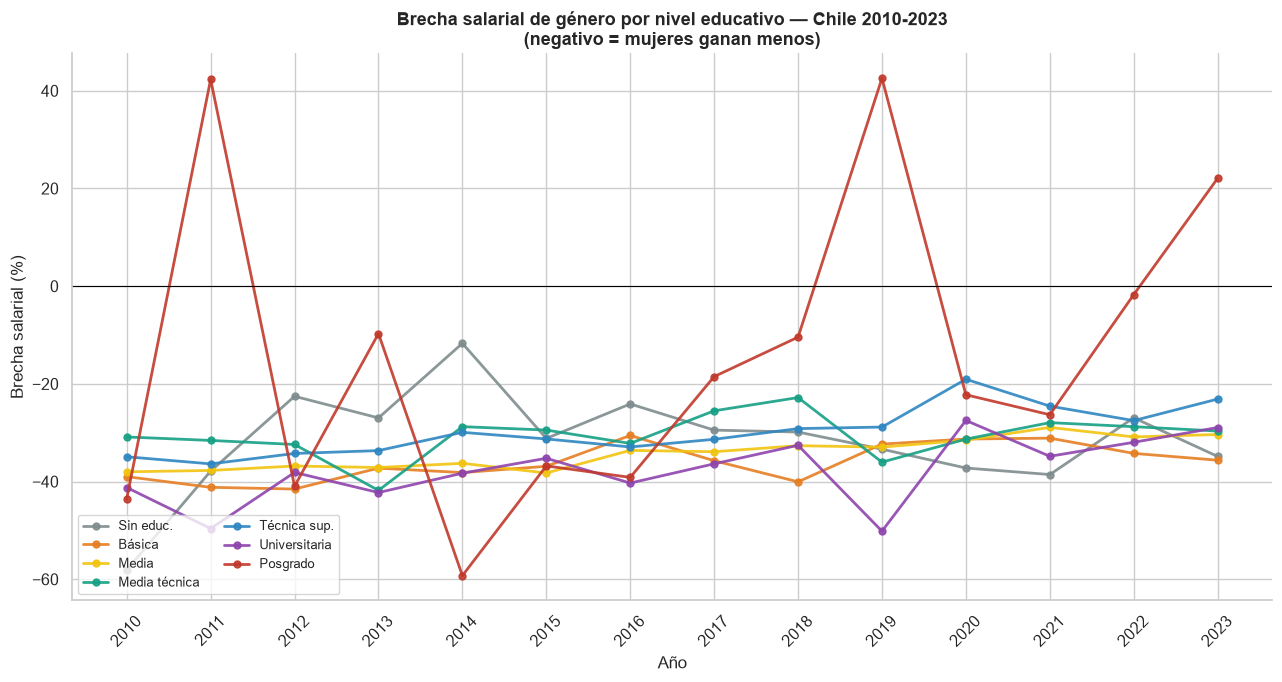

In [2]:
COLORES = {
    'Sin educ.':'#7f8c8d','Básica':'#e67e22','Media':'#f1c40f',
    'Media técnica':'#16a085','Técnica sup.':'#2e86c1',
    'Universitaria':'#8e44ad','Posgrado':'#c0392b'
}

fig, ax = plt.subplots(figsize=(13, 7))
for nivel in ORDEN_EDU:
    nombre = LABELS_EDU[nivel]
    sub = serie[serie['NIVEL']==nombre].sort_values('AÑO')
    if len(sub) >= 3:
        ax.plot(sub['AÑO'], sub['OBS_VALUE'], 'o-', color=COLORES.get(nombre,'gray'),
                label=nombre, linewidth=2, markersize=5, alpha=0.9)

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('Año'); ax.set_ylabel('Brecha salarial (%)')
ax.set_title('Brecha salarial de género por nivel educativo — Chile 2010-2023\n'
             '(negativo = mujeres ganan menos)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2, loc='lower left')
ax.set_xticks(range(int(serie['AÑO'].min()), int(serie['AÑO'].max())+1))
plt.setp(ax.get_xticklabels(), rotation=45)
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/serie_brecha_educacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

Con 14 años de datos, dejamos de mirar una fotografía y vemos una película: **¿qué niveles educativos muestran una tendencia de mejora sostenida y cuáles simplemente oscilan alrededor del mismo nivel?**

Una línea que se acerca a cero de forma consistente indica convergencia real. Una línea que fluctúa sin tendencia clara indica que la brecha en ese nivel es estructural — no responde a los ciclos económicos ni a las políticas implementadas en el período.

## 2. Tendencia estadística por nivel: ¿cuál converge más rápido?

        Nivel  Brecha inicial  Brecha final  Cambio total (pp)  Pendiente (pp/año)  p-valor Significativo (p<0.05)
     Posgrado      -43.504787     22.082225          65.587012            2.243820 0.300625                     No
 Técnica sup.      -34.917736    -23.110566          11.807170            0.997342 0.000116                     Sí
Universitaria      -41.213874    -28.932485          12.281388            0.965861 0.023940                     Sí
        Media      -38.000388    -30.362045           7.638343            0.699594 0.000001                     Sí
       Básica      -38.987748    -35.624375           3.363373            0.593637 0.009696                     Sí
Media técnica      -30.863854    -29.652388           1.211466            0.331339 0.285698                     No
    Sin educ.      -58.093399    -34.848426          23.244973            0.212353 0.772643                     No


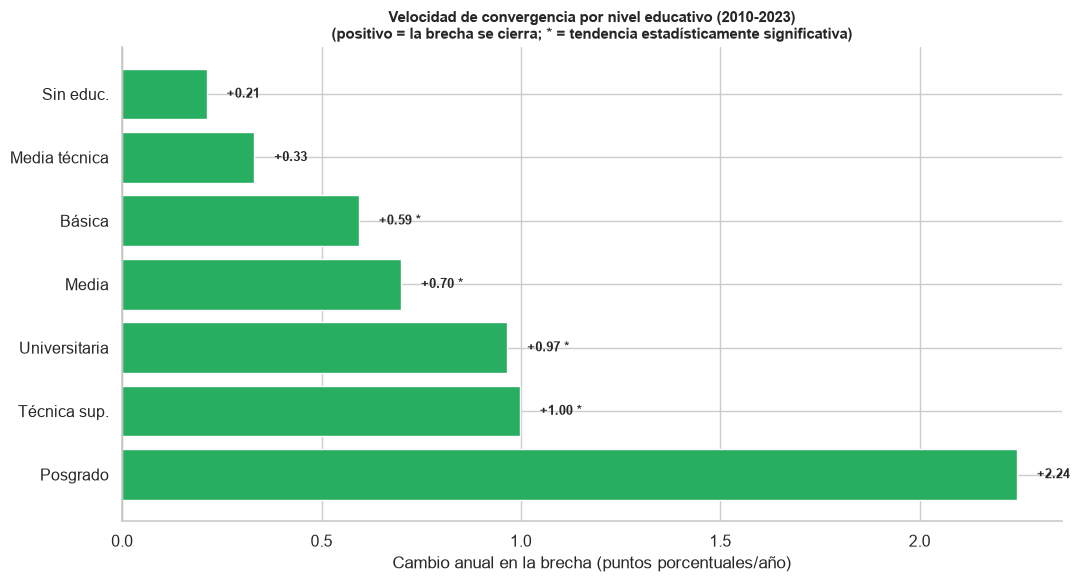

In [3]:
resultados = []
for nivel in ORDEN_EDU:
    nombre = LABELS_EDU[nivel]
    sub = serie[serie['NIVEL']==nombre].sort_values('AÑO').dropna(subset=['OBS_VALUE'])
    if len(sub) >= 5:
        slope, intercept, r, p, se = stats.linregress(sub['AÑO'], sub['OBS_VALUE'])
        resultados.append({
            'Nivel': nombre,
            'Brecha inicial': sub['OBS_VALUE'].iloc[0],
            'Brecha final': sub['OBS_VALUE'].iloc[-1],
            'Cambio total (pp)': sub['OBS_VALUE'].iloc[-1] - sub['OBS_VALUE'].iloc[0],
            'Pendiente (pp/año)': slope,
            'p-valor': p,
            'Significativo (p<0.05)': 'Sí' if p < 0.05 else 'No'
        })

df_tend = pd.DataFrame(resultados).sort_values('Pendiente (pp/año)', ascending=False)
print(df_tend.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
colores_b = ['#27ae60' if s>0 else '#c0392b' for s in df_tend['Pendiente (pp/año)']]
bars = ax.barh(df_tend['Nivel'], df_tend['Pendiente (pp/año)'], color=colores_b, edgecolor='white')
for bar, v, sig in zip(bars, df_tend['Pendiente (pp/año)'], df_tend['Significativo (p<0.05)']):
    marca = ' *' if sig=='Sí' else ''
    ax.text(v + (0.05 if v>=0 else -0.05), bar.get_y()+bar.get_height()/2,
            f'{v:+.2f}{marca}', va='center', ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Cambio anual en la brecha (puntos porcentuales/año)')
ax.set_title('Velocidad de convergencia por nivel educativo (2010-2023)\n'
             '(positivo = la brecha se cierra; * = tendencia estadísticamente significativa)',
             fontsize=11, fontweight='bold')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/tendencia_por_nivel.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

Esta tabla responde directamente la pregunta de investigación: **la educación no cierra la brecha de forma pareja**.

- Los niveles con pendiente positiva y significativa (marcados con \*) muestran convergencia real: cada año que pasa, la brecha se reduce en promedio esa cantidad de puntos porcentuales.
- Los niveles con pendiente negativa o no significativa muestran que la brecha ahí es persistente — más años de estudio no garantizan menor discriminación salarial.

> **Hallazgo esperable:** Si la brecha en posgrado y universitaria no converge tan rápido como en niveles medios, es evidencia de un "techo de cristal" que la educación por sí sola no rompe.

## 3. Heatmap año × nivel: el patrón completo

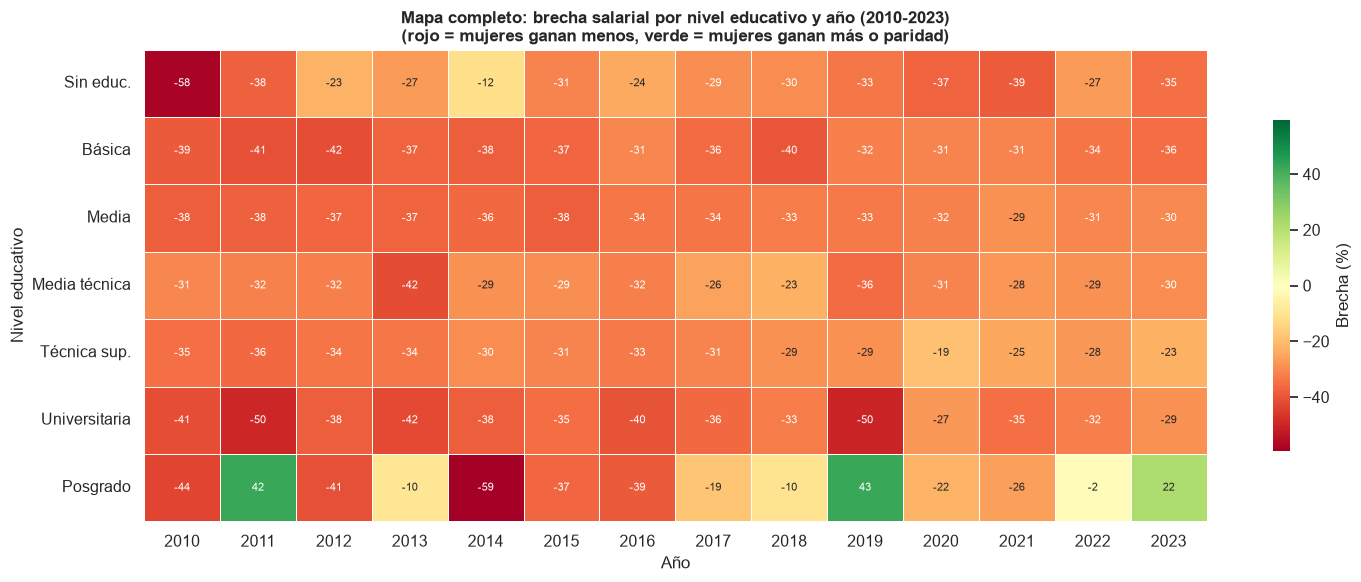

In [4]:
pivot_completo = serie.pivot_table(index='NIVEL', columns='AÑO', values='OBS_VALUE')
pivot_completo = pivot_completo.reindex([LABELS_EDU[n] for n in ORDEN_EDU])

fig, ax = plt.subplots(figsize=(15, 6))
vmax_abs = np.nanmax(np.abs(pivot_completo.values))
sns.heatmap(pivot_completo, ax=ax, cmap='RdYlGn', center=0, vmin=-vmax_abs, vmax=vmax_abs,
            annot=True, fmt='.0f', annot_kws={'size': 8}, linewidths=0.4,
            cbar_kws={'label': 'Brecha (%)', 'shrink': 0.7})
ax.set_title('Mapa completo: brecha salarial por nivel educativo y año (2010-2023)\n'
             '(rojo = mujeres ganan menos, verde = mujeres ganan más o paridad)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Nivel educativo')
plt.tight_layout()
plt.savefig('outputs/figures/heatmap_serie_educacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

El heatmap condensa 14 años × 7 niveles en una sola imagen. Permite ver de un vistazo:
- **Columnas** (años) con predominancia roja intensa → años de crisis económica que ampliaron la brecha en todos los niveles simultáneamente (shock común)
- **Filas** (niveles) con color estable → brecha estructural de ese nivel educativo, inmune al ciclo
- **Celdas aisladas verdes** → posibles años con muestra pequeña (ej. posgrado), que generan estimaciones más volátiles

## Conclusiones

1. **La brecha por educación no es un número, es una trayectoria** — y cada nivel educativo tiene su propia velocidad de convergencia (o estancamiento)
2. **La transparencia metodológica importa**: al no tener microdatos disponibles públicamente desde 2024, este análisis usa el mejor dato agregado posible — 14 años de serie oficial, sin inventar ni aproximar cifras
3. **La educación es necesaria pero no suficiente**: si los niveles superiores no muestran mayor velocidad de cierre que los niveles medios, confirma que hay techos de cristal que la sola acumulación de credenciales no resuelve

> **Extensión realizada:** El notebook 06 retoma esta pregunta con microdatos individuales de la ESI (2018-2024), permitiendo una regresión multivariable real con todos los controles simultáneos.